# Resumen

c

In [22]:
%load_ext autoreload
%autoreload 2

from cross_sectional import *

warnings.filterwarnings("ignore", module="statsmodels.tsa.stattools")
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
df = gpd.read_parquet(r"D:\yannis_data\Descargas\airbnb_bcn_clean.parquet")

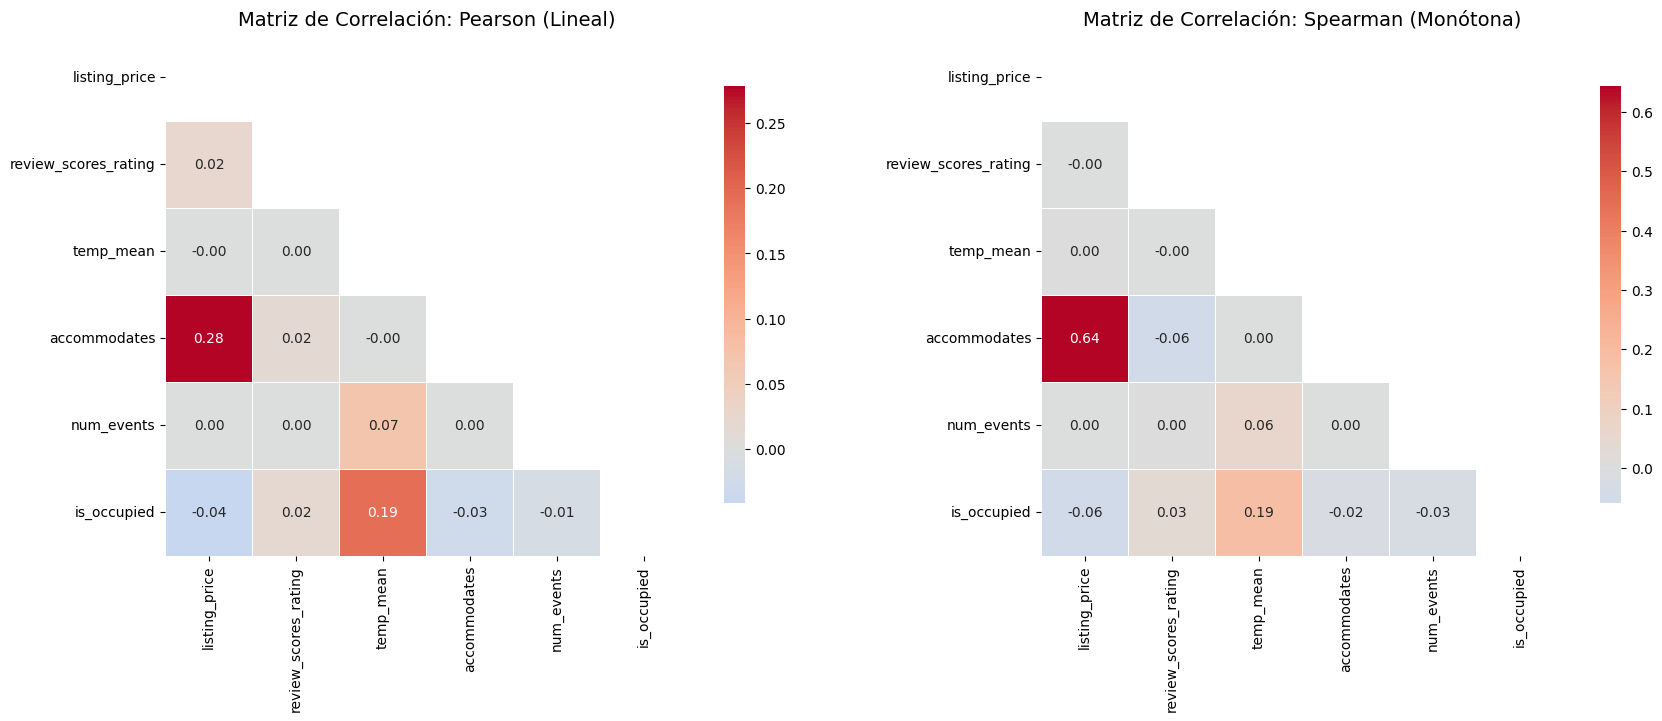


FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
            Variable      VIF
       listing_price 1.084589
        accommodates 1.084241
           temp_mean 1.004764
          num_events 1.004761
review_scores_rating 1.000704
--------------------------------------------------
Regla: VIF > 5 (Precaución), VIF > 10 (Multicolinealidad severa).

COMPARACIÓN DE DISTRIBUCIONES (TEST DE KRUSKAL-WALLIS)
Var: listing_price          | Estadístico (H):  13641.73 | p-valor: 0.0000e+00 | Difieren: ✅ SÍ
Var: review_scores_rating   | Estadístico (H):   3247.84 | p-valor: 0.0000e+00 | Difieren: ✅ SÍ
Var: temp_mean              | Estadístico (H): 109810.52 | p-valor: 0.0000e+00 | Difieren: ✅ SÍ
Var: accommodates           | Estadístico (H):   2090.33 | p-valor: 0.0000e+00 | Difieren: ✅ SÍ
Var: num_events             | Estadístico (H):   3222.43 | p-valor: 0.0000e+00 | Difieren: ✅ SÍ

ASOCIACIÓN CATEGÓRICA (CHI2 Y V DE CRAMER)
Var: room_type          | Chi2 p-valor: 0.0000e+00 | V-Cramer: 0.0263 | Asociació

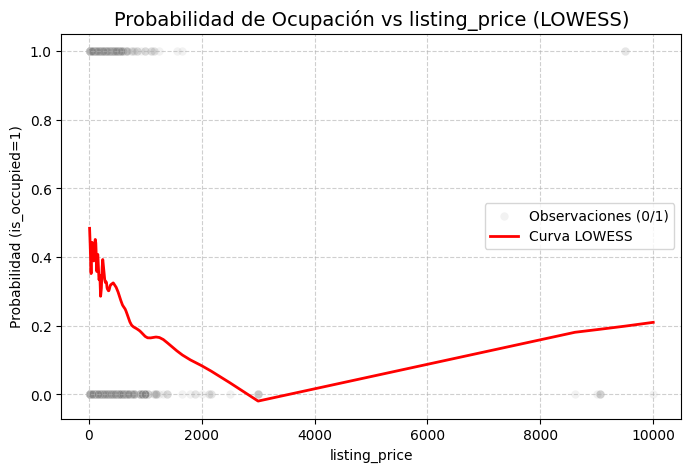

[+] Calculando LOWESS para review_scores_rating (Muestra: 10000 registros)...


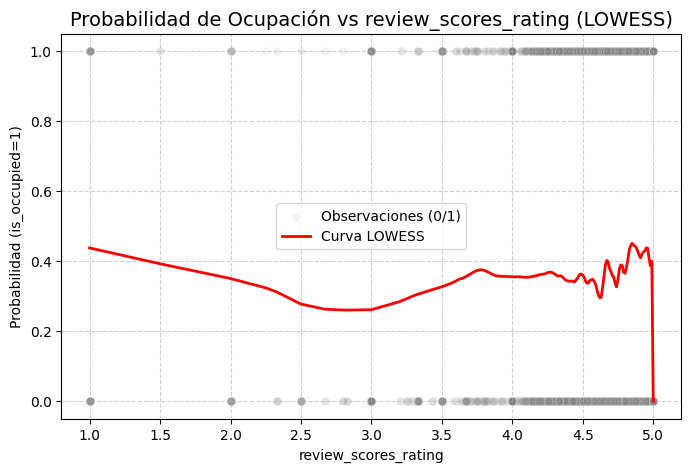

[+] Calculando LOWESS para temp_mean (Muestra: 10000 registros)...


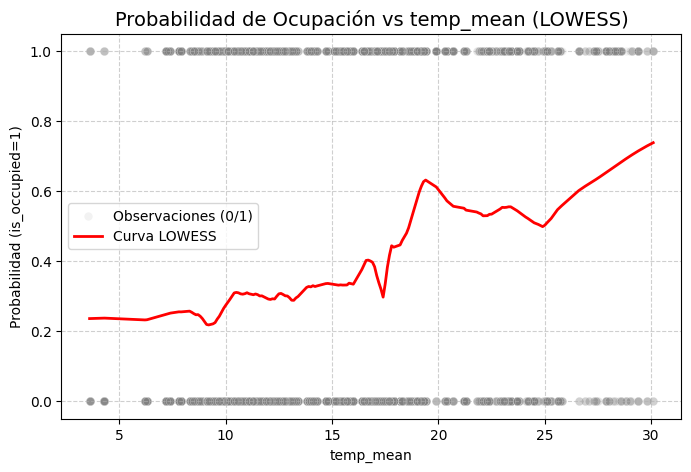

In [23]:
# Mapeo estricto de tus variables
target_var = 'is_occupied'

# Todas las numéricas (continuas + discretas) para Correlaciones, VIF y T-Student
num_vars = [
    'listing_price', 
    'review_scores_rating', 
    'temp_mean', 
    'accommodates', 
    'num_events'
]

# Solo las estrictamente continuas para la regresión local LOWESS
cont_vars = [
    'listing_price', 
    'review_scores_rating', 
    'temp_mean'
]

# Categóricas para Chi2
cat_vars = [
    'room_type', 
    'is_holiday', 
    'instant_bookable'
]


plot_correlation_matrices(df, num_vars, target=target_var)
calculate_vif(df, num_vars)
compare_groups_kruskal(df, num_vars, target=target_var)
analyze_categorical_associations(df, cat_vars, target=target_var)
plot_lowess_analysis(df, cont_vars, target=target_var, frac=0.1)


🧠 INFORMACIÓN MUTUA (MUTUAL INFORMATION)
[+] Calculando MI para 8 variables sobre 2911148 registros...


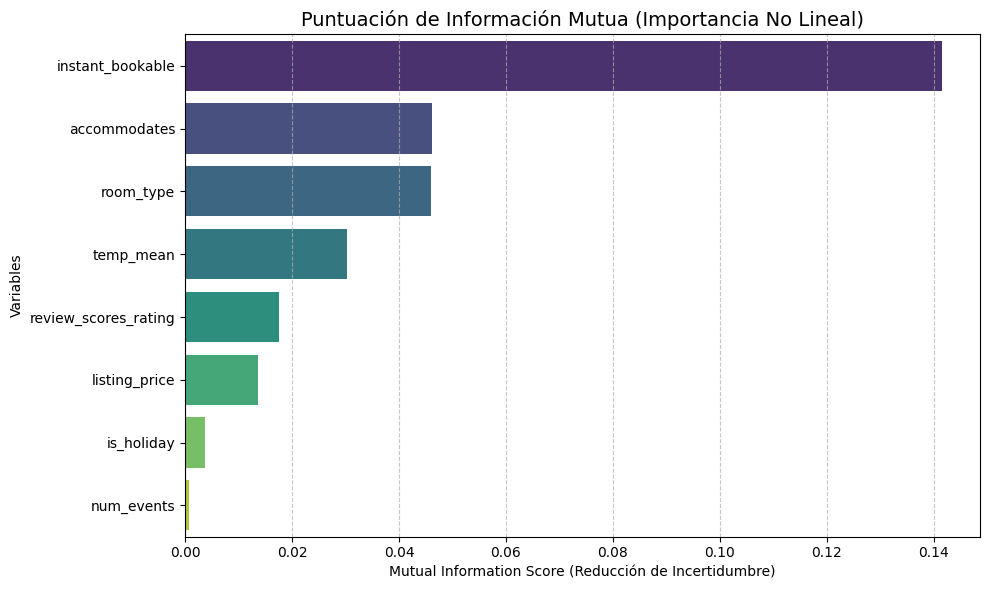

                      MI Score
instant_bookable      0.141569
accommodates          0.046231
room_type             0.045934
temp_mean             0.030263
review_scores_rating  0.017510
listing_price         0.013695
is_holiday            0.003682
num_events            0.000730
------------------------------------------------------------
Regla: MI = 0 (Totalmente independientes).
       MI > 0 (Existe relación detectada, captura patrones NO lineales).


In [16]:
target_var = 'is_occupied'

# Todas tus variables transversales que hemos analizado
all_features = [
    'listing_price', 
    'review_scores_rating', 
    'temp_mean', 
    'accommodates', 
    'num_events',
    'room_type', 
    'is_holiday', 
    'instant_bookable'
]

plot_mutual_information(df, all_features, target=target_var)